<a href="https://colab.research.google.com/github/WSmithDR/machine-learning-project/blob/main/Proyecto_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Datos atípicos

In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_train = pd.read_csv('datos/inicial/vehiculos_train.csv')
df_test = pd.read_csv('datos/inicial/vehiculos_test.csv')

## millas_recorridas

In [13]:
df_train['millas_recorridas'].describe()

count    1.936640e+05
mean     4.867635e+04
std      4.004901e+04
min     -1.991700e+04
25%      1.464700e+04
50%      4.000000e+04
75%      7.557125e+04
max      1.080000e+06
Name: millas_recorridas, dtype: float64

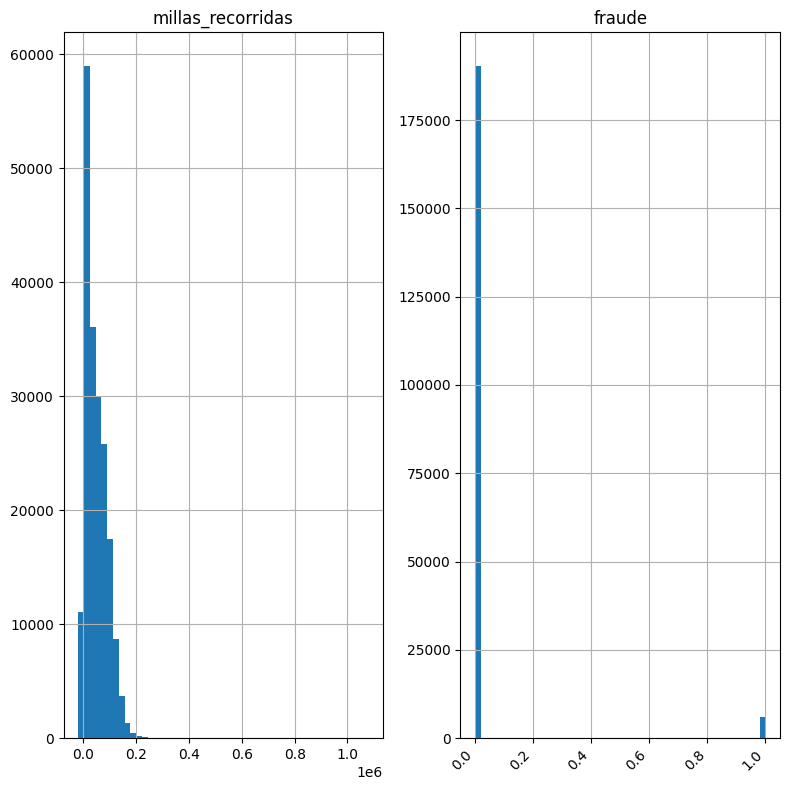

In [11]:
df_train[['millas_recorridas','fraude']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

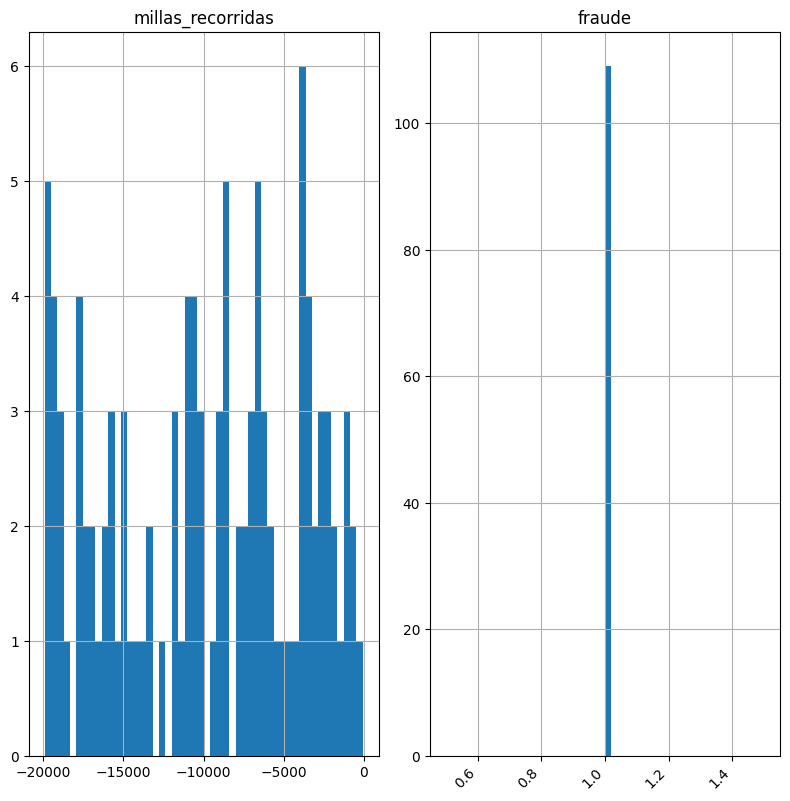

In [15]:
df_train.loc[df_train['millas_recorridas']<0,['millas_recorridas','fraude']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()



In [16]:
df_test['millas_recorridas'].describe()


count    2.151000e+04
mean     4.920080e+04
std      5.913809e+04
min     -1.979300e+04
25%      1.447875e+04
50%      4.005400e+04
75%      7.600000e+04
max      6.363342e+06
Name: millas_recorridas, dtype: float64

In [19]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21826 entries, 0 to 21825
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   index                   21826 non-null  int64  
 1   marca                   21826 non-null  object 
 2   modelo                  19719 non-null  object 
 3   color                   21281 non-null  object 
 4   anio_registro           21298 non-null  float64
 5   tipo_vehiculo           21826 non-null  object 
 6   millas_recorridas       21510 non-null  float64
 7   tamanio_motor           21717 non-null  object 
 8   transmision             21826 non-null  object 
 9   tipo_combustible        21826 non-null  object 
 10  precio_vehiculo         20805 non-null  float64
 11  num_asientos            21826 non-null  float64
 12  num_puertas             21826 non-null  float64
 13  problema_averia         21826 non-null  object 
 14  id_problema_averia      21826 non-null

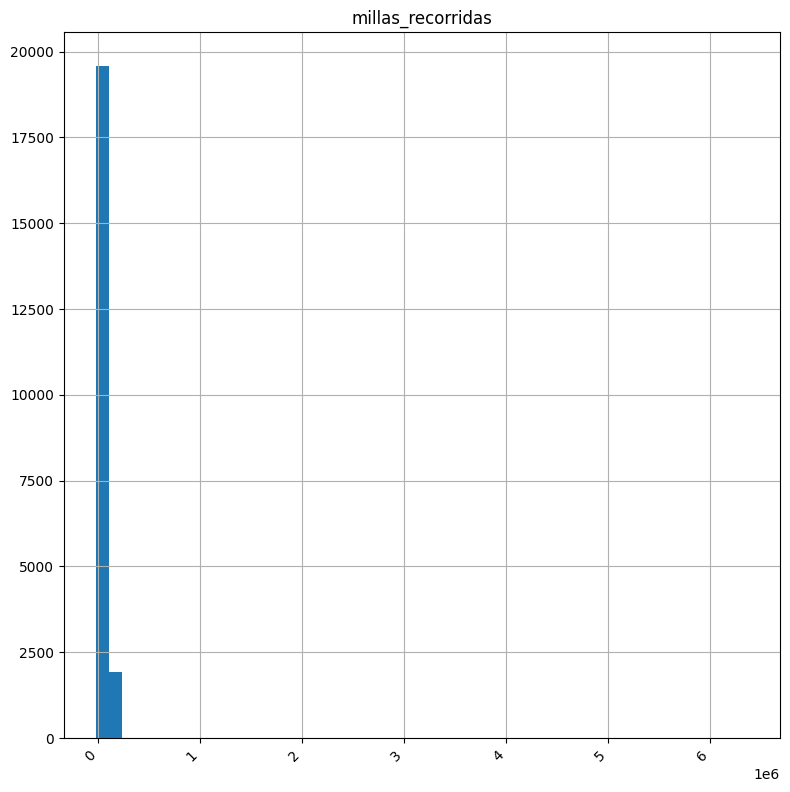

In [21]:
df_test[['millas_recorridas']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()


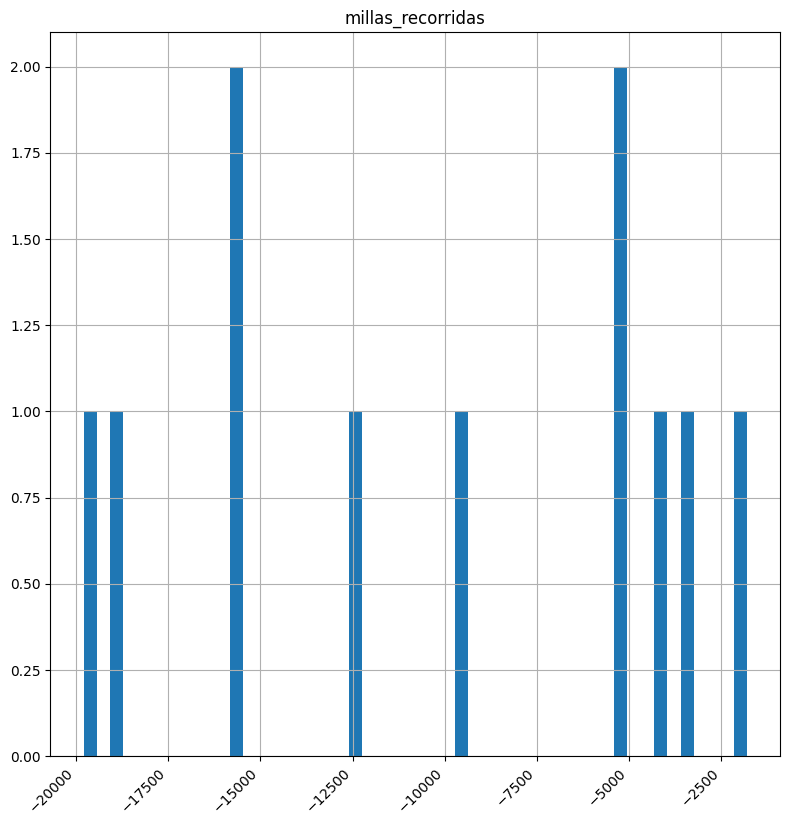

In [23]:
df_test.loc[df_test['millas_recorridas']<0,['millas_recorridas']].hist(bins=50, figsize=(8,8))
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

Hasta ahora hemos visto que casi la totalidad de los casos de fraude están en los vehiculos con millaje negativo, por lo que eliminar dichos valores no es una opción. Todo parece indicar un error de tipeo a la hora de registrar estos valores, por lo que procederemos a realizar dicha correccion.

In [24]:
df_train['millas_recorridas'] = df_train['millas_recorridas'].abs()


Nos aseguramos que el valor minimo ahora sea cero.

In [ ]:
df_train['millas_recorridas'].describe()

count    1.936640e+05
mean     4.868746e+04
std      4.003550e+04
min      0.000000e+00
25%      1.465575e+04
50%      4.000000e+04
75%      7.557125e+04
max      1.080000e+06
Name: millas_recorridas, dtype: float64

In [27]:
df_test['millas_recorridas'] = df_test['millas_recorridas'].abs()


Nos aseguramos que el valor minimo ahora sea cero.

In [28]:
df_test['millas_recorridas'].describe()


count    2.151000e+04
mean     4.921120e+04
std      5.912943e+04
min      0.000000e+00
25%      1.449375e+04
50%      4.005400e+04
75%      7.600000e+04
max      6.363342e+06
Name: millas_recorridas, dtype: float64

In [31]:
import os

# Create the directory structure if it doesn't exist
os.makedirs('datos/preprocesados', exist_ok=True)

# Now save the files
df_train.to_csv('datos/preprocesados/vehiculos_train_sin_millas_negativas.csv', index=False)
df_test.to_csv('datos/preprocesados/vehiculos_test_sin_millas_negativas.csv', index=False)
